# 01. 二次関数

Phase 1 の最初の単元。前回(二次方程式)の**平方完成**を、今度は「グラフの頂点を求める」
道具として使います。

> **なぜ ML/LLM に必要か**: 機械学習の学習とは「損失関数を最小にするパラメータを探す」こと。
> 二次関数は最も単純な損失関数であり、その頂点(最小値)を求める操作は
> 勾配降下法が一般の関数に対してやっていることの原点です。


In [5]:
# 答え合わせ用ヘルパー(このセルを最初に実行してください)
import hashlib
from fractions import Fraction

def check(answer, expected_hash):
    h = hashlib.md5(str(answer).encode()).hexdigest()[:8]
    print("✅ 正解!" if h == expected_hash else "❌ 不正解。もう一度考えてみよう")


## 1. 学習内容

説明のすぐ下に、その場で確認できるコード・グラフを置いています。

### おさらい: 平方完成とは

前回(二次方程式)で少し出てきた**平方完成**を、簡単な例で思い出しておく。

$$x^2 + 6x = (x + 3)^2 - 9$$

これは「$x^2+6x$ に $3^2=9$ を足して $(x+3)^2$ を作り、勝手に足した分を引いて帳尻を合わせる」という変形。
やることはいつも同じ3手順:

1. $x$ の係数を半分にする($6 \to 3$)
2. それを2乗したものを足して、同じ数を引く($+3^2 - 3^2$)
3. 足した分まで含めた前半3項が $(x+3)^2$ にまとまる

一般化すると $x^2 + kx = \left(x + \dfrac{k}{2}\right)^2 - \left(\dfrac{k}{2}\right)^2$。
今回はこの技を「二次関数のグラフの頂点を求める」道具として使う。


In [6]:
import sympy as sp

x = sp.symbols('x')

# おさらい: x^2 + 6x = (x+3)^2 - 9 を展開して確認
print(sp.expand((x + 3)**2 - 9) == sp.expand(x**2 + 6*x))  # → True


True


### 基本形とグラフ

$y = ax^2$ のグラフは放物線。$a > 0$ なら下に凸、$a < 0$ なら上に凸。
$|a|$ が大きいほど細く、小さいほど広がる。


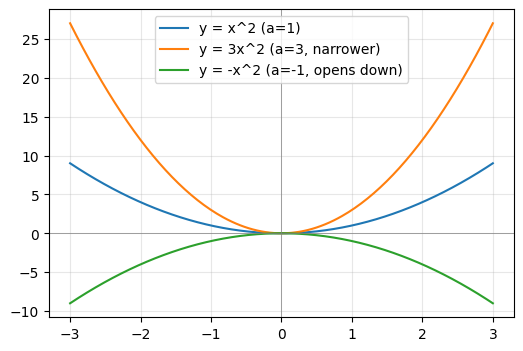

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# a の符号・大きさでグラフの形がどう変わるか
xs = np.linspace(-3, 3, 200)

plt.figure(figsize=(6, 4))
plt.plot(xs, xs**2, label="y = x^2 (a=1)")
plt.plot(xs, 3*xs**2, label="y = 3x^2 (a=3, narrower)")
plt.plot(xs, -xs**2, label="y = -x^2 (a=-1, opens down)")
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 頂点形とは何か

一般形 $y = ax^2 + bx + c$ を見ただけでは、グラフの頂点(一番低い/高い点)がどこにあるか分からない
(実際に $x$ にいくつか数値を代入して計算しないと見えてこない)。

そこでもし式を

$$y = a(x - p)^2 + q$$

の形に書き直せたとする。$(x-p)^2$ は2乗なので常に $0$ 以上。したがって:

- $a > 0$ のとき: $(x-p)^2 = 0$ になる $x=p$ で $y$ は最小値 $q$。それ以外の $x$ では $(x-p)^2>0$ の分だけ $y$ が大きくなる
- $a < 0$ のとき: 同じ理屈で $x=p$ が最大値 $q$

つまりこの形は**式を眺めるだけで頂点 $(p, q)$ が分かる**特別な形になっている。
これを**頂点形**と呼ぶ(一般形 $ax^2+bx+c$ と対になる呼び方)。下のグラフで確認する。


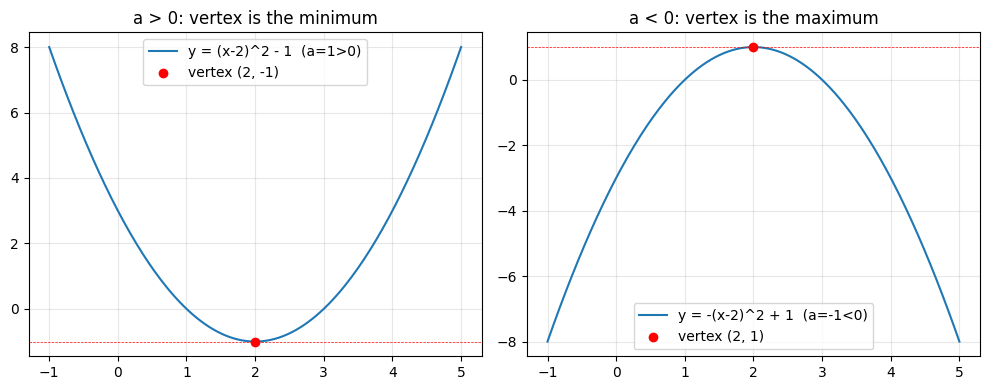

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 頂点形とは何か: (x-p)^2 >= 0 だから、x=p でちょうど0になり、
# それ以外では (x-p)^2 の分だけ y が押し上げ/押し下げられる、という様子を図で確認
p, q = 2, -1
xs = np.linspace(p - 3, p + 3, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(xs, (xs - p)**2 + q, label="y = (x-2)^2 - 1  (a=1>0)")
axes[0].scatter([p], [q], color="red", zorder=5, label=f"vertex ({p}, {q})")
axes[0].axhline(q, color="red", lw=0.5, linestyle="--")
axes[0].set_title("a > 0: vertex is the minimum")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(xs, -(xs - p)**2 - q, label="y = -(x-2)^2 + 1  (a=-1<0)")
axes[1].scatter([p], [-q], color="red", zorder=5, label=f"vertex ({p}, {-q})")
axes[1].axhline(-q, color="red", lw=0.5, linestyle="--")
axes[1].set_title("a < 0: vertex is the maximum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 頂点形の作り方(平方完成で変形する)

では一般形から頂点形はどう作るか。おさらいした平方完成をそのまま使う。
具体例 $y = 2x^2 - 8x + 3$ で試す:

$$
\begin{aligned}
y &= 2x^2 - 8x + 3 \\
&= 2(x^2 - 4x) + 3
&&\text{① } a=2 \text{ でくくる($x^2$ と $x$ の項だけ)} \\
&= 2\left[(x - 2)^2 - 4\right] + 3
&&\text{② おさらいの手順で平方完成(半分の2乗} (-4/2)^2=4 \text{ を引く)} \\
&= 2(x - 2)^2 - 8 + 3
&&\text{③ かっこを展開して } a \text{ を掛け戻す} \\
&= 2(x - 2)^2 - 5
&&\text{④ 定数をまとめる}
\end{aligned}
$$

これで**頂点形** $y = 2(x-2)^2 - 5$ が得られた。頂点は $(2, -5)$。


In [2]:
import sympy as sp

x = sp.symbols('x')

# 具体例 y = 2x^2 - 8x + 3 で、頂点形 2(x-2)^2 - 5 に展開しても一致することを確認
original = 2*x**2 - 8*x + 3
vertex_form = 2*(x - 2)**2 - 5

print(sp.expand(original) == sp.expand(vertex_form))  # → True


True


**同じ4ステップを文字 $a, b, c$ のまま**やると一般公式になる:

$$
\begin{aligned}
y &= ax^2 + bx + c \\
&= a\left(x^2 + \frac{b}{a}x\right) + c
&&\text{① } a \text{ でくくる} \\
&= a\left[\left(x + \frac{b}{2a}\right)^2 - \frac{b^2}{4a^2}\right] + c
&&\text{② 平方完成} \\
&= a\left(x + \frac{b}{2a}\right)^2 - \frac{b^2}{4a} + c
&&\text{③ } a \text{ を掛け戻す} \\
&= a\left(x + \frac{b}{2a}\right)^2 - \frac{b^2 - 4ac}{4a}
&&\text{④ 定数をまとめる}
\end{aligned}
$$

$$y = a(x - p)^2 + q, \quad (p, q) = \left(-\dfrac{b}{2a},\; -\dfrac{b^2 - 4ac}{4a}\right)$$

具体例と見比べると、①〜④のどのステップも文字を数字に置き換えただけなのが分かるはず。

これは前回の解の公式を導出した式と同じもの(分子の符号が違うだけ)。
**二次方程式は「$y=0$ になる $x$」を、二次関数は「頂点」を求める** という関係です。


In [3]:
import sympy as sp

x, a, b, c = sp.symbols('x a b c')

# 同じことを文字 a, b, c のまま確認(①〜④の手順を一般化しただけ)
p = -b / (2*a)
q = -(b**2 - 4*a*c) / (4*a)
vertex_form_general = a * (x - p)**2 + q

print(sp.expand(vertex_form_general) == sp.expand(a*x**2 + b*x + c))  # → True


True


### 最大値・最小値(まとめ)

- $a > 0$(下に凸): 頂点 $x = p$ で**最小値** $q$ を取る
- $a < 0$(上に凸): 頂点 $x = p$ で**最大値** $q$ を取る

### 平行移動

$y = a(x - p)^2 + q$ のグラフは、$y = ax^2$ のグラフを
$x$ 軸方向に $p$、$y$ 軸方向に $q$ だけ平行移動したもの。


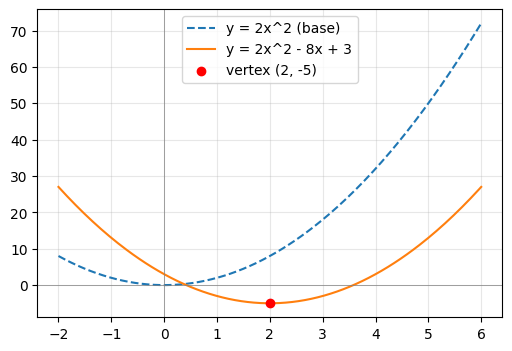

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 平方完成の具体例をグラフで確認: y=2x^2 (基準) を平行移動すると
# y=2x^2-8x+3 = 2(x-2)^2-5 になり、頂点が (2, -5) に移る
xs = np.linspace(-2, 6, 200)

plt.figure(figsize=(6, 4))
plt.plot(xs, 2*xs**2, label="y = 2x^2 (base)", linestyle="--")
plt.plot(xs, 2*xs**2 - 8*xs + 3, label="y = 2x^2 - 8x + 3")
plt.scatter([2], [-5], color="red", zorder=5, label="vertex (2, -5)")
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 2. 実装課題

一般形の係数 `a, b, c` から頂点 `(p, q)` を返す関数 `vertex(a, b, c)` を実装してください。
戻り値はタプル `(p, q)` です(分数になる場合は `fractions.Fraction` で返すと厳密に一致します)。


In [2]:
from fractions import Fraction

def vertex(a, b, c):
    """y = ax^2 + bx + c の頂点 (p, q) を返す"""
    # ここを実装する(ヒント: p = -b/(2a), q = -(b**2 - 4*a*c)/(4*a))
    p = Fraction(-b, (2*a))
    q = Fraction(-(b**2 - 4*a*c), 4*a)
    return (p, q)


In [3]:
# テスト: sympy の平方完成と照合する
import sympy as sp

x = sp.symbols('x')
cases = [(1, -4, 5), (-2, 8, -3), (2, 4, 1), (1, -3, 1)]
results = []
for a, b, c in cases:
    got = vertex(a, b, c)
    p_expected, q_expected = sp.symbols('p q')
    completed = sp.factor_terms(sp.Poly(a*x**2 + b*x + c, x).as_expr())
    p_true = sp.Rational(-b, 2*a)
    q_true = sp.simplify(a*p_true**2 + b*p_true + c)
    ok = got is not None and sp.Rational(got[0]) == p_true and sp.Rational(got[1]) == q_true
    results.append(ok)

if all(results):
    print("✅ すべて一致!実装完了")
else:
    ng = [c for c, ok in zip(cases, results) if not ok]
    print(f"❌ 一致しないケースがあります: {ng}")


✅ すべて一致!実装完了


## 3. 練習問題

`answer = None` を書き換えて実行してください。答えは**整数または `Fraction`** で。

> まず紙(または頭)で平方完成してから答えを入れてください。


In [6]:
# 【問題1】y = x² − 4x + 5 の頂点 (p, q) を求めよ

# y = x² − 4x + 5
# y = [(x - 2)² - 4] + 5
# y = (x - 2)² + 1

# (2, 1)

answer_p = 2  # ← 頂点のx座標
answer_q = 1  # ← 頂点のy座標
check(answer_p, "c81e728d")
check(answer_q, "c4ca4238")


✅ 正解!
✅ 正解!


In [7]:
# 【問題2】y = −2x² + 8x − 3 の最大値を求めよ

# y の最大値 = 頂点のy

# y = -2x² + 8x - 3
# y = -2(x² - 4x) - 3
# y = -2[(x - 2)² - 4] - 3
# y = -2(x - 2)² + 8 - 3
# y = -2(x - 2)² + 5

answer = 5  # ← ここを書き換える
check(answer, "e4da3b7f")


✅ 正解!


In [8]:
# 【問題3】y = 2x² + 4x + 1 を a(x−p)² + q の形に平方完成したとき、q の値を求めよ

# y = 2x² + 4x + 1
# y = 2(x² + 2x) + 1
# y = 2[(x² + 1) - 1] + 1
# y = 2(x² + 1) - 2 + 1
# y = 2(x² + 1) - 1

answer = -1  # ← ここを書き換える
check(answer, "6bb61e3b")


✅ 正解!


In [11]:
# 【問題4】y = x² − 3x + 1 の頂点のy座標を求めよ(Fraction になる)

# y = x² − 3x + 1
# y = (x - 3/2)² - (3/2)² + 1
# y = (x - 3/2)² - (3/2)² + 1
# y = (x - 3/2)² - (3/2 * 3/2) + 1
# y = (x - 3/2)² - 9/4 + 1
# y = (x - 3/2)² - 5/4

answer = Fraction(-5, 4)  # ← Fraction(分子, 分母) で
check(answer, "0ad1d777")


✅ 正解!


In [12]:
# 【問題5】y = (x−3)² + 2 のグラフを x軸方向に −1、y軸方向に +3 だけ平行移動した
# グラフの頂点 (x, y) を求めよ

# 元の頂点 (3, 2)
# 移動後の頂点 (2, 5)

answer_x = 2  # ← 頂点のx座標
answer_y = 5  # ← 頂点のy座標
check(answer_x, "c81e728d")
check(answer_y, "e4da3b7f")


✅ 正解!
✅ 正解!


In [13]:
# 【問題6】損失関数 L(w) = 3(w−4)² + 2 を最小にする w と、そのときの最小値を求めよ

# 式はすでに頂点形
# 頂点は (4, 2)

answer_w = 4    # ← 最小値を与える w
answer_min = 2  # ← そのときの最小値
check(answer_w, "a87ff679")
check(answer_min, "c81e728d")


✅ 正解!
✅ 正解!


In [14]:
# 【問題7】y = x² + kx + 9 のグラフがx軸に接する(重解を持つ)とき、正の k の値を求めよ
# (ヒント: 判別式 D = k² − 36 = 0)

# 判別式から k を求める
# D = k² − 36 = 0
# D = 6² - 36 = 0
# よって k = 6

answer = 6  # ← ここを書き換える
check(answer, "1679091c")


✅ 正解!


## 4. 解答・解説

<details><summary>解答を見る</summary>

**問題1: p = `2`, q = `1`** —
$x^2 - 4x + 5 = (x-2)^2 + 1$

**問題2: `5`** —
頂点の $x$ 座標は $-\dfrac{8}{2 \cdot (-2)} = 2$、$y = -2(2)^2+8(2)-3 = 5$。$a<0$ なのでこれが最大値

**問題3: `-1`** —
$2x^2+4x+1 = 2(x^2+2x)+1 = 2\big[(x+1)^2-1\big]+1 = 2(x+1)^2 - 1$

**問題4: `Fraction(-5, 4)`** —
頂点の $x$ 座標は $\dfrac{3}{2}$、$y = \left(\dfrac{3}{2}\right)^2 - 3\cdot\dfrac{3}{2} + 1 = \dfrac{9}{4} - \dfrac{18}{4} + \dfrac{4}{4} = -\dfrac{5}{4}$。
分数の頂点も平方完成の手順は同じ

**問題5: x = `2`, y = `5`** —
頂点 $(3, 2)$ を $x$ 方向に $-1$、$y$ 方向に $+3$ 動かすと $(3-1,\ 2+3) = (2, 5)$

**問題6: w = `4`, 最小値 = `2`** —
$(w-4)^2 \geq 0$ なので、最小になるのは $w=4$ のとき。そのとき $L=2$。
「二乗の項が0になる点が最小点」という考え方は、勾配降下法が損失曲面の底を探すのと同じ発想です

**問題7: `6`** —
$D = k^2 - 4\cdot1\cdot9 = k^2-36$。接する条件 $D=0$ より $k=\pm6$、正の方は $6$

**実装課題の例**:

```python
from fractions import Fraction

def vertex(a, b, c):
    p = Fraction(-b, 2*a)
    q = -Fraction(b**2 - 4*a*c, 4*a)
    return (p, q)
```

次は指数・対数(数II)。ML で頻出の対数尤度・クロスエントロピーの土台になります。

</details>
